<a href="https://colab.research.google.com/github/OthmaneAbder2303/Practical-Deep-Learning/blob/main/'Object%20Detection'/yolo_coin_model_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Verify NVIDIA GPU Availability**

Make sure you're using a GPU-equipped machine by going to "Runtime" -> "Change runtime type" in the top menu bar, and then selecting one of the GPU options in the Hardware accelerator section. Click Play on the following code block to verify that the NVIDIA GPU is present and ready for training.

In [ ]:
!nvidia-smi

Fri May  1 21:10:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

#1.&nbsp;Gather and Label Training Images

# 2.&nbsp;Upload Image Dataset and Prepare Training Data

Next, we'll upload our dataset and prepare it for training with YOLO. We'll split the dataset into train and validation folders, and we'll automatically generate the configuration file for training the model.

## 2.1 Upload images

First, we need to upload the dataset to Colab. Here are a few options for moving the `data.zip` folder into this Colab instance.

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

!cp /content/gdrive/MyDrive/YOLO_coin_data_12DEC30.zip /content

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


## 2.2 Split images into train and validation folders

Next, we'll unzip `YOLO_coin_data_12DEC30.zip` and create some folders to hold the images. Run the following code block to unzip the data.

In [ ]:
# Unzip images to a custom data folder
!unzip -q /content/YOLO_coin_data_12DEC30 -d /content/custom_YOLO_coin_data_12DEC30

replace /content/custom_YOLO_coin_data_12DEC30/classes.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/custom_YOLO_coin_data_12DEC30/images/IMG_3387.JPG? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/custom_YOLO_coin_data_12DEC30/images/IMG_3388.JPG? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/custom_YOLO_coin_data_12DEC30/images/IMG_3389.JPG? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/custom_YOLO_coin_data_12DEC30/images/IMG_3390.JPG? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

Ultralytics requires a particular folder structure to store training data for models. Ultralytics requires a particular folder structure to store training data for models. The root folder is named “data”. Inside, there are two main folders:

*   **Train**: These are the actual images used to train the model. In one epoch of training, every image in the train set is passed into the neural network. The training algorithm adjusts the network weights to fit the data in the images.


*   **Validation**: These images are used to check the model's performance at the end of each training epoch.

In each of these folders is a “images” folder and a “labels” folder, which hold the image files and annotation files respectively.


I wrote a Python script that will automatically create the required folder structure and randomly move 90% of dataset to the "train" folder and 10% to the "validation" folder. Run the following code block to download and execute the scrpt.

In [ ]:
!wget -O /content/train_val_split.py https://raw.githubusercontent.com/EdjeElectronics/Train-and-Deploy-YOLO-Models/refs/heads/main/utils/train_val_split.py

# TO DO: Improve robustness of train_val_split.py script so it can handle nested data folders, etc
!python train_val_split.py --datapath="/content/custom_YOLO_coin_data_12DEC30" --train_pct=0.9

--2026-05-01 21:28:58--  https://raw.githubusercontent.com/EdjeElectronics/Train-and-Deploy-YOLO-Models/refs/heads/main/utils/train_val_split.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3203 (3.1K) [text/plain]
Saving to: ‘/content/train_val_split.py’

/content/train_val_ 100%[===================>]   3.13K  --.-KB/s    in 0s      

2026-05-01 21:28:58 (56.5 MB/s) - ‘/content/train_val_split.py’ saved [3203/3203]

Created folder at /content/data/train/images.
Created folder at /content/data/train/labels.
Created folder at /content/data/validation/images.
Created folder at /content/data/validation/labels.
Number of image files: 750
Number of annotation files: 750
Images moving to train: 675
Images moving to validation: 75


# 3.&nbsp;Install Requirements (Ultralytics)

Next, we'll install the Ultralytics library in this Google Colab instance. This Python library will be used to train the YOLO model.

In [ ]:
!pip install ultralytics

# 4.&nbsp;Configure Training


There's one last step before we can run training: we need to create the Ultralytics training configuration YAML file. This file specifies the location of your train and validation data, and it also defines the model's classes. An example configuration file model is available [here](https://github.com/ultralytics/ultralytics/blob/main/ultralytics/cfg/datasets/coco128.yaml).

Run the code block below to automatically generate a `coin_data.yaml` configuration file. Make sure you have a labelmap file located at `custom_YOLO_coin_data_12DEC30/classes.txt`. If you used Label Studio or one of my pre-made datasets, it should already be present. If you assembled the dataset another way, you may have to manually create the `classes.txt` file (see [here](https://github.com/EdjeElectronics/Train-and-Deploy-YOLO-Models/blob/main/doc/classes.txt) for an example of how it's formatted).

In [ ]:
# Python function to automatically create coin_data.yaml config file
# 1. Reads "classes.txt" file to get list of class names
# 2. Creates data dictionary with correct paths to folders, number of classes, and names of classes
# 3. Writes data in YAML format to data.yaml

import yaml
import os

def create_data_yaml(path_to_classes_txt, path_to_data_yaml):

  # Read class.txt to get class names
  if not os.path.exists(path_to_classes_txt):
    print(f'classes.txt file not found! Please create a classes.txt labelmap and move it to {path_to_classes_txt}')
    return
  with open(path_to_classes_txt, 'r') as f:
    classes = []
    for line in f.readlines():
      if len(line.strip()) == 0: continue
      classes.append(line.strip())
  number_of_classes = len(classes)

  # Create data dictionary
  data = {
      'path': '/content/data',
      'train': 'train/images',
      'val': 'validation/images',
      'nc': number_of_classes,
      'names': classes
  }

  # Write data to YAML file
  with open(path_to_data_yaml, 'w') as f:
    yaml.dump(data, f, sort_keys=False)
  print(f'Created config file at {path_to_data_yaml}')

  return

# Define path to classes.txt and run function
path_to_classes_txt = '/content/custom_YOLO_coin_data_12DEC30/classes.txt'
path_to_data_yaml = '/content/coin_data.yaml'

create_data_yaml(path_to_classes_txt, path_to_data_yaml)

print('\nFile contents:\n')
!cat /content/coin_data.yaml

Created config file at /content/coin_data.yaml

File contents:

path: /content/data
train: train/images
val: validation/images
nc: 4
names:
- penny
- nickel
- dime
- quarter


# 5.&nbsp;Train Model

## 5.1 Training Parameters
Now that the data is organized and the config file is created, we're ready to start training! First, there are a few important parameters to decide on.

**Model architecture & size (`model`):**

There are several YOLO11 models sizes available to train, including `yolo11n.pt`, `yolo11s.pt`, `yolo11m.pt`, `yolo11l.pt`, and `yolo11xl.pt`. Larger models run slower but have higher accuracy, while smaller models run faster but have lower accuracy. If we are not sure which model size to use, `yolo11s.pt` is a good starting point.

We can also train YOLOv8 or YOLOv5 models by substituting `yolo11` for `yolov8` or `yolov5`.


**Number of epochs (`epochs`)**

In machine learning, one “epoch” is one single pass through the full training dataset. Setting the number of epochs dictates how long the model will train for. The best amount of epochs to use depends on the size of the dataset and the model architecture. If your dataset has less than 200 images, a good starting point is 60 epochs. If our dataset has more than 200 images, a good starting point is 40 epochs.


**Resolution (`imgsz`)**

Resolution has a large impact on the speed and accuracy of the model: a lower resolution model will have higher speed but less accuracy. YOLO models are typically trained and inferenced at a 640x640 resolution. However, if we want our model to run faster or know we will be working with low-resolution images, a lower resolution like 480x480 will be good.


## 5.2 Run Training!

In [ ]:
!yolo detect train data=/content/coin_data.yaml model=yolo11s.pt epochs=60 imgsz=640

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/coin_data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, persp

The training algorithm will parse the images in the training and validation directories and then start training the model. At the end of each training epoch, the program runs the model on the validation dataset and reports the resulting mAP, precision, and recall. As training continues, the mAP should generally increase with each epoch. Training will end once it goes through the number of epochs specified by `epochs`.

> **NOTE:** Make sure to allow training to run to completion, because an optimizer runs at the end of training that strips out unneeded layers from the model.

The best trained model weights will be saved in `content/runs/detect/train/weights/best.pt`. Additional information about training is saved in the `content/runs/detect/train` folder, including a `results.png` file that shows how loss, precision, recall, and mAP progressed over each epoch.

#6.&nbsp;Test Model

The model has been trained; now it's time to test it! The commands below run the model on the images in the validation folder and then display the results for the first 10 images. This is a good way to confirm your model is working as expected. Click Play on the blocks below to see how your model performs.

In [ ]:
!yolo detect predict model=runs/detect/train/weights/best.pt source=data/validation/images save=True

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,414,348 parameters, 0 gradients, 21.3 GFLOPs

image 1/75 /content/data/validation/images/IMG_3387.JPG: 640x480 1 penny, 3 nickels, 1 quarter, 61.6ms
image 2/75 /content/data/validation/images/IMG_3390.JPG: 640x480 1 penny, 2 nickels, 1 dime, 1 quarter, 10.9ms
image 3/75 /content/data/validation/images/IMG_3402.JPG: 640x480 1 penny, 1 dime, 2 quarters, 10.8ms
image 4/75 /content/data/validation/images/IMG_3444.JPG: 640x480 1 penny, 1 nickel, 10.8ms
image 5/75 /content/data/validation/images/IMG_3446.JPG: 640x480 1 penny, 1 dime, 10.8ms
image 6/75 /content/data/validation/images/IMG_3450.JPG: 640x480 3 pennys, 10.8ms
image 7/75 /content/data/validation/images/IMG_3456.JPG: 640x480 1 penny, 1 nickel, 1 quarter, 11.9ms
image 8/75 /content/data/validation/images/IMG_3463.JPG: 640x480 1 nickel, 1 dime, 12.5ms
image 9/75 /content/data/validation/images/IMG_3969.JPG: 480x64

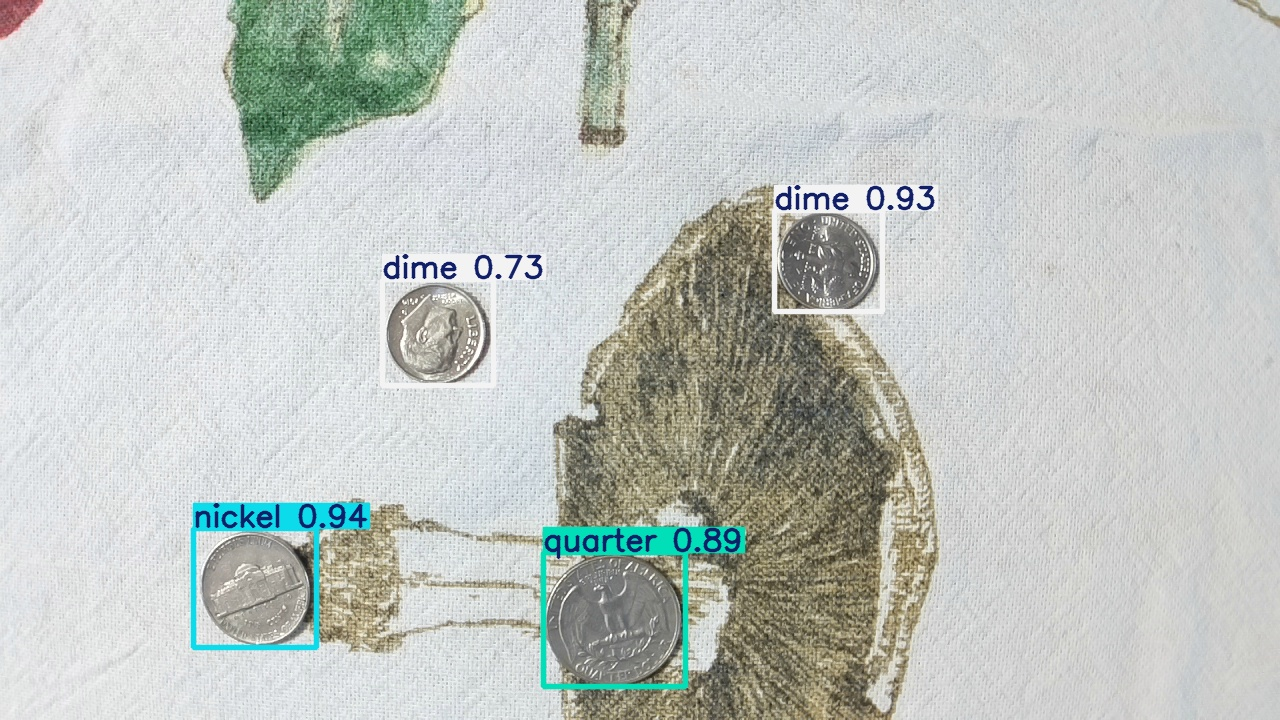

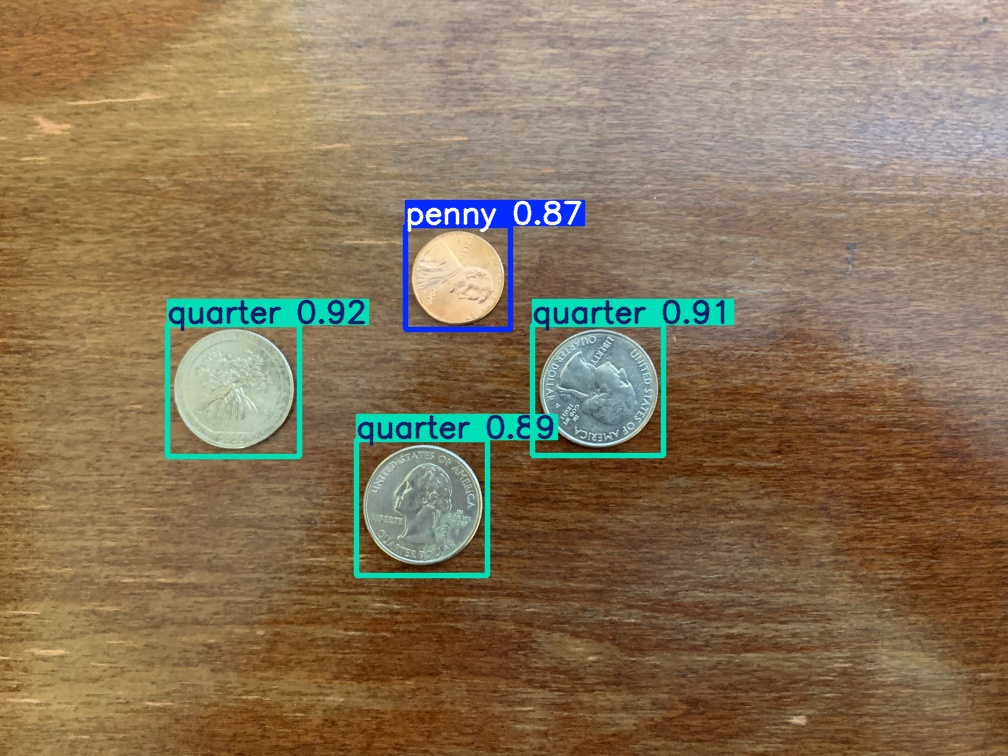

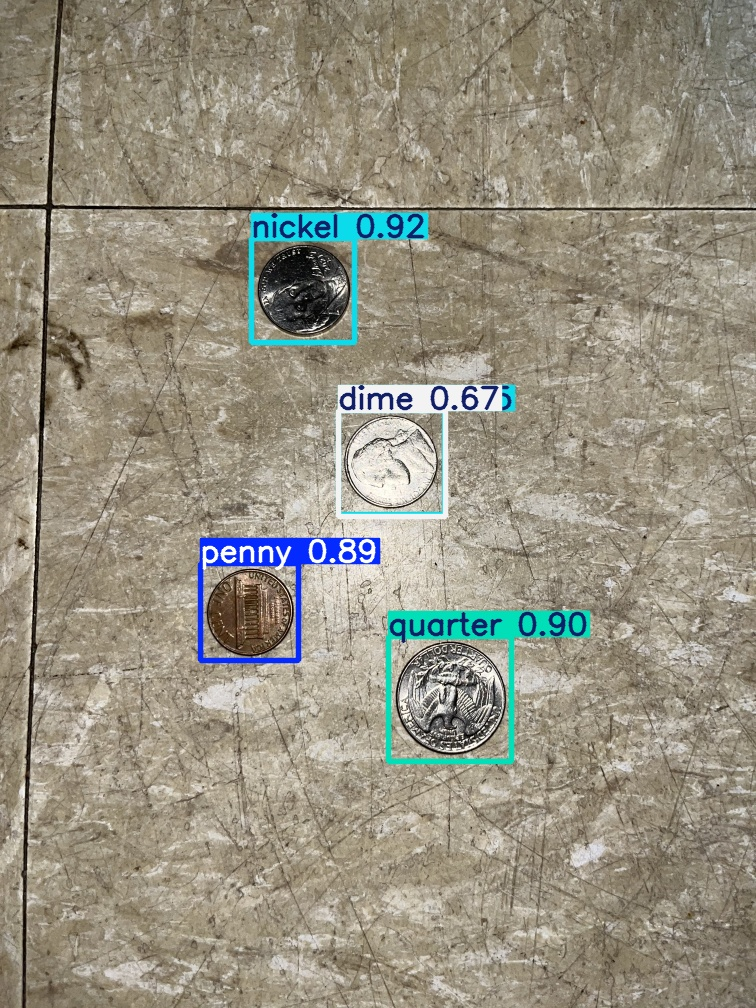

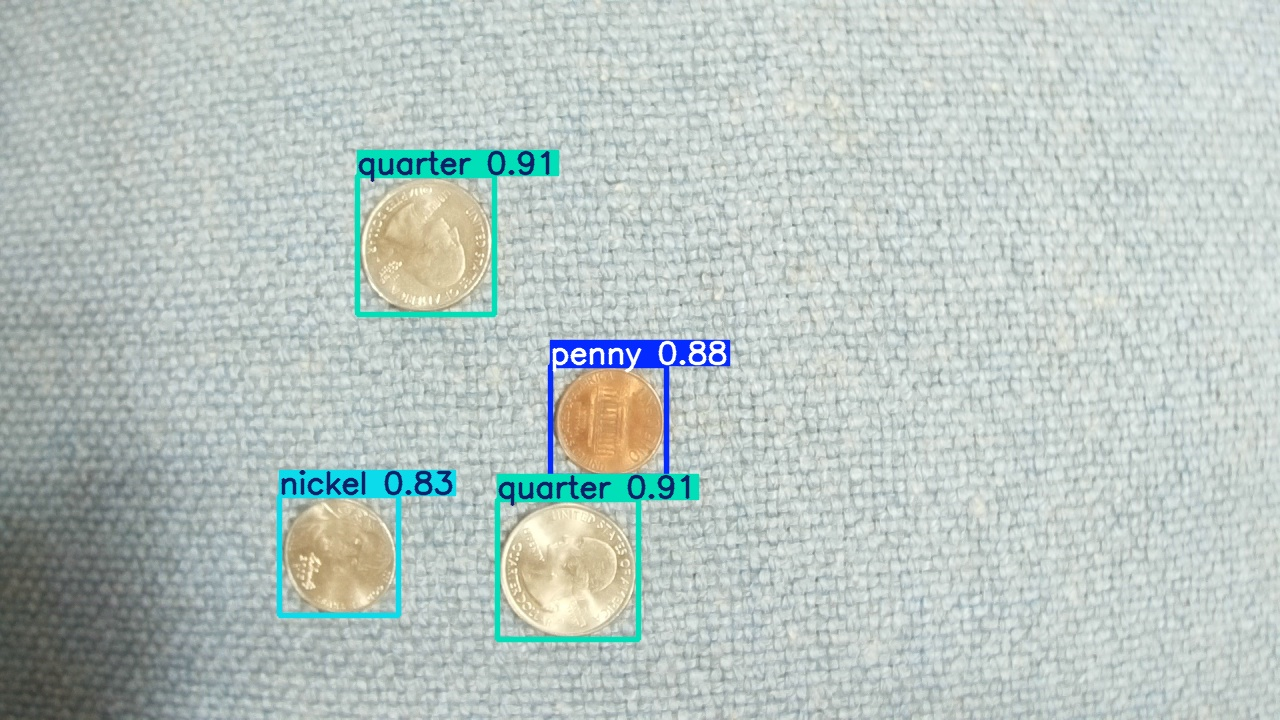

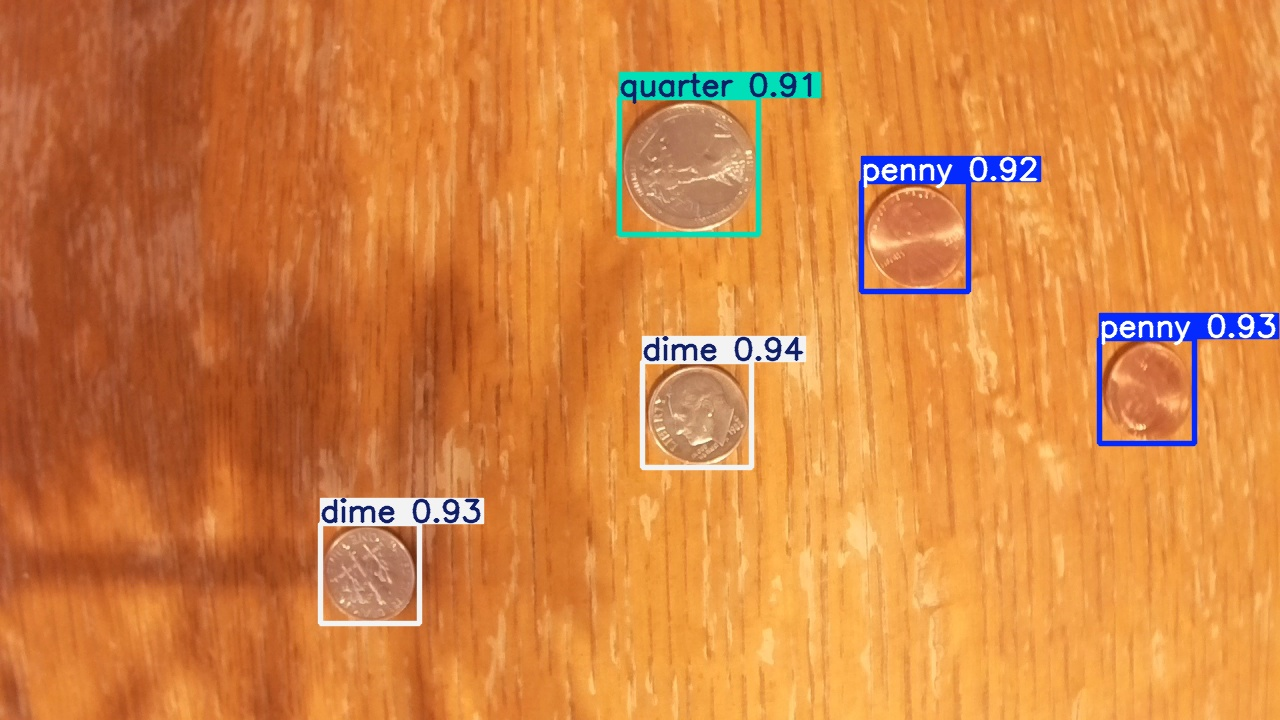

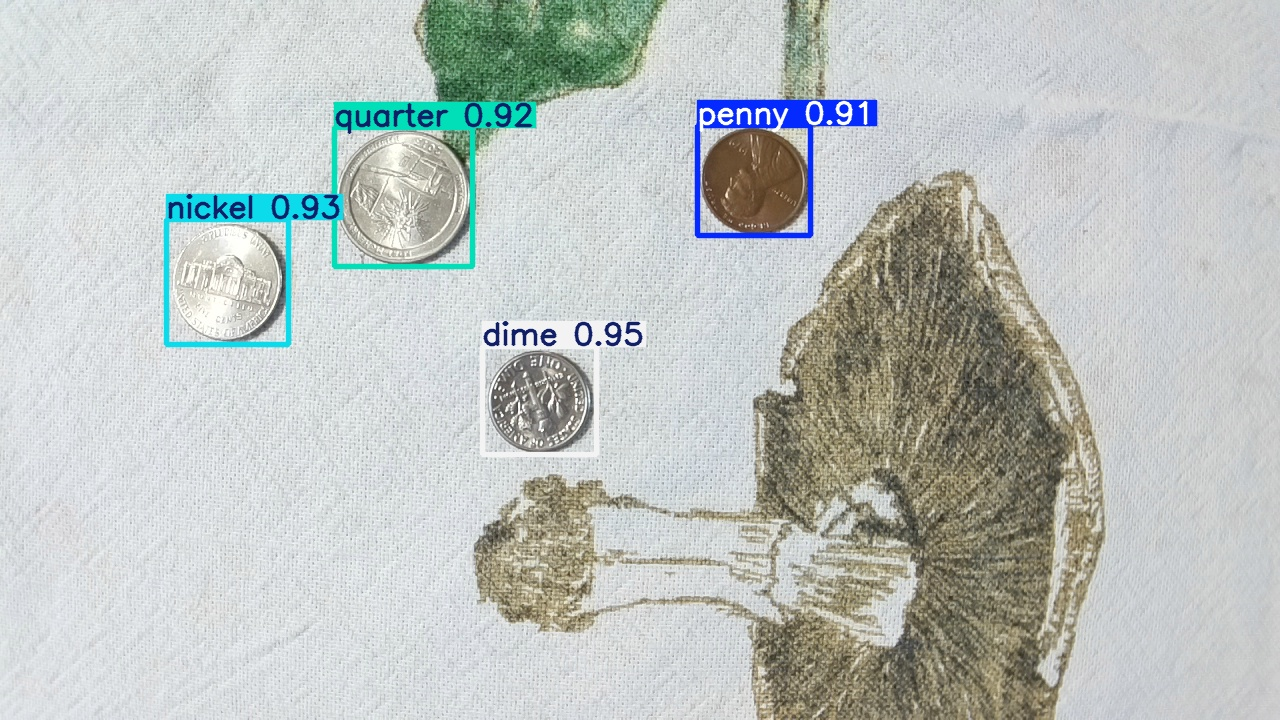

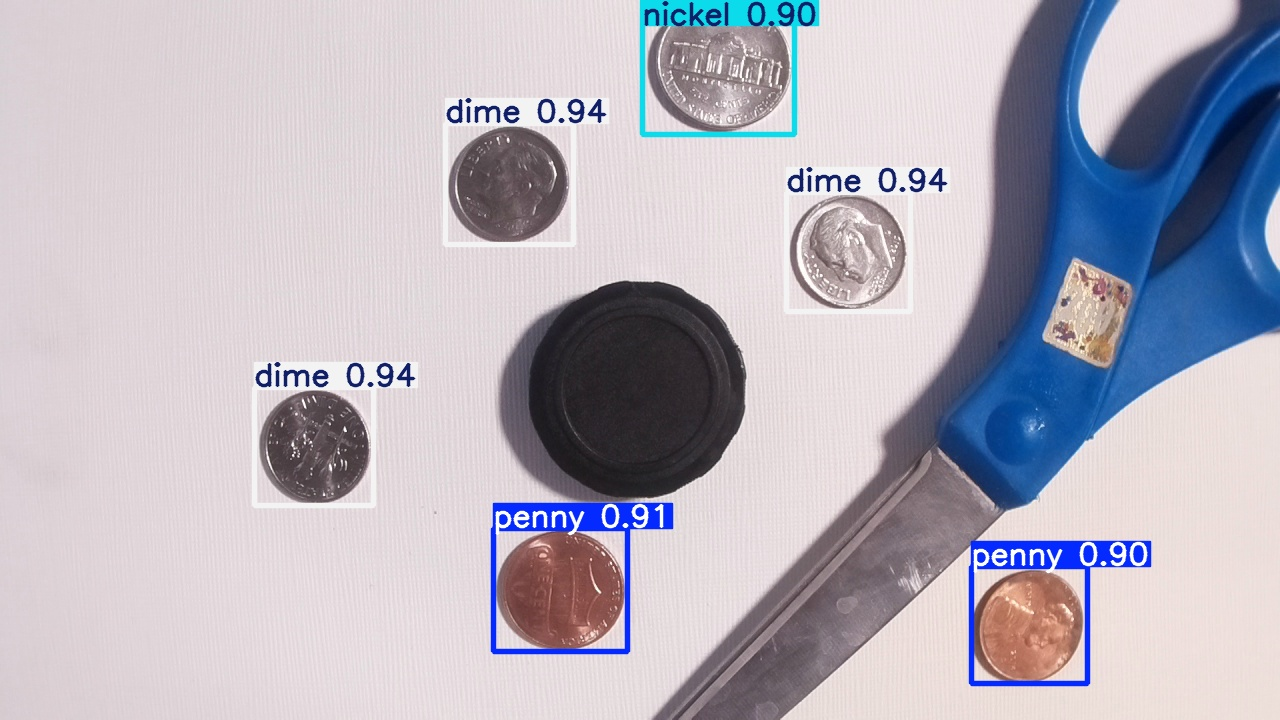

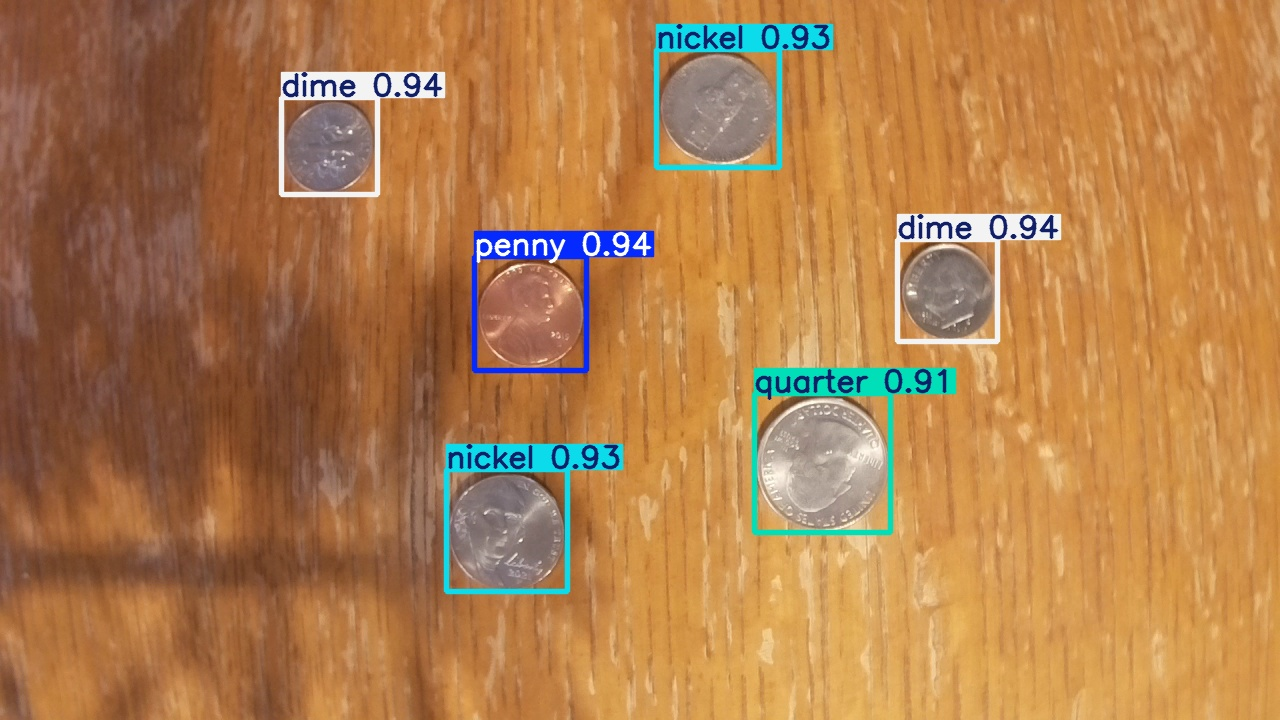

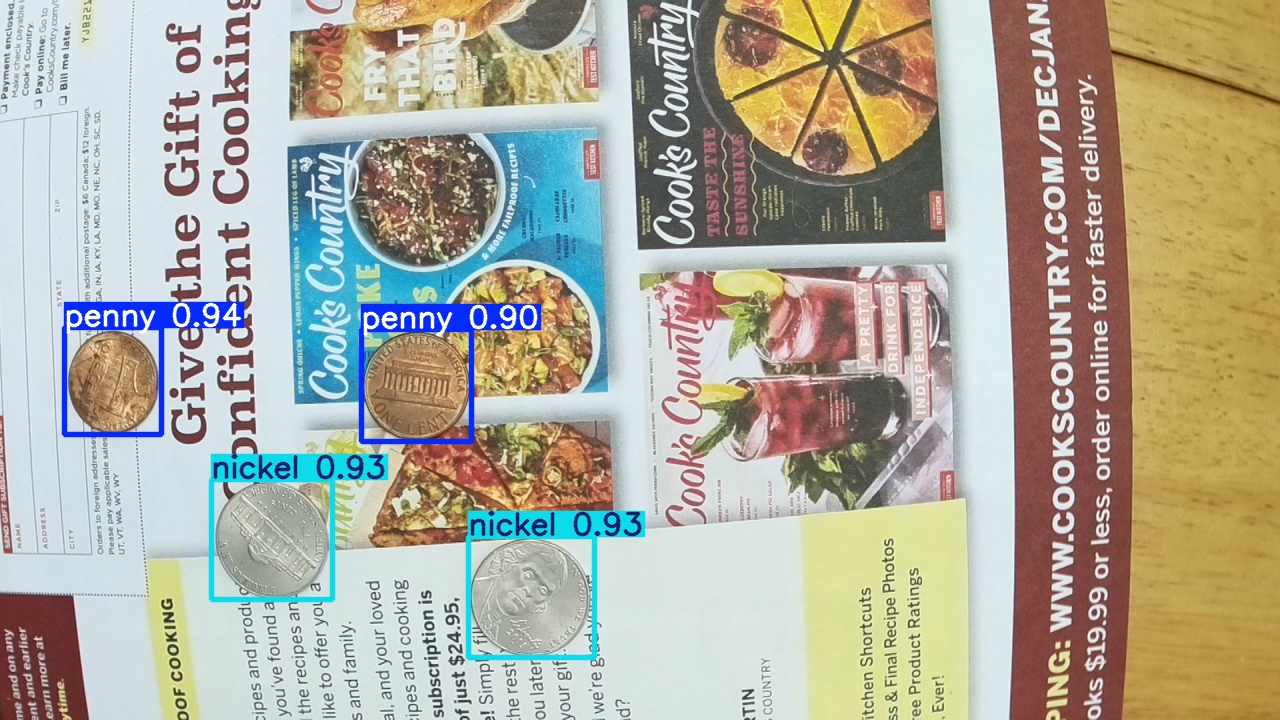

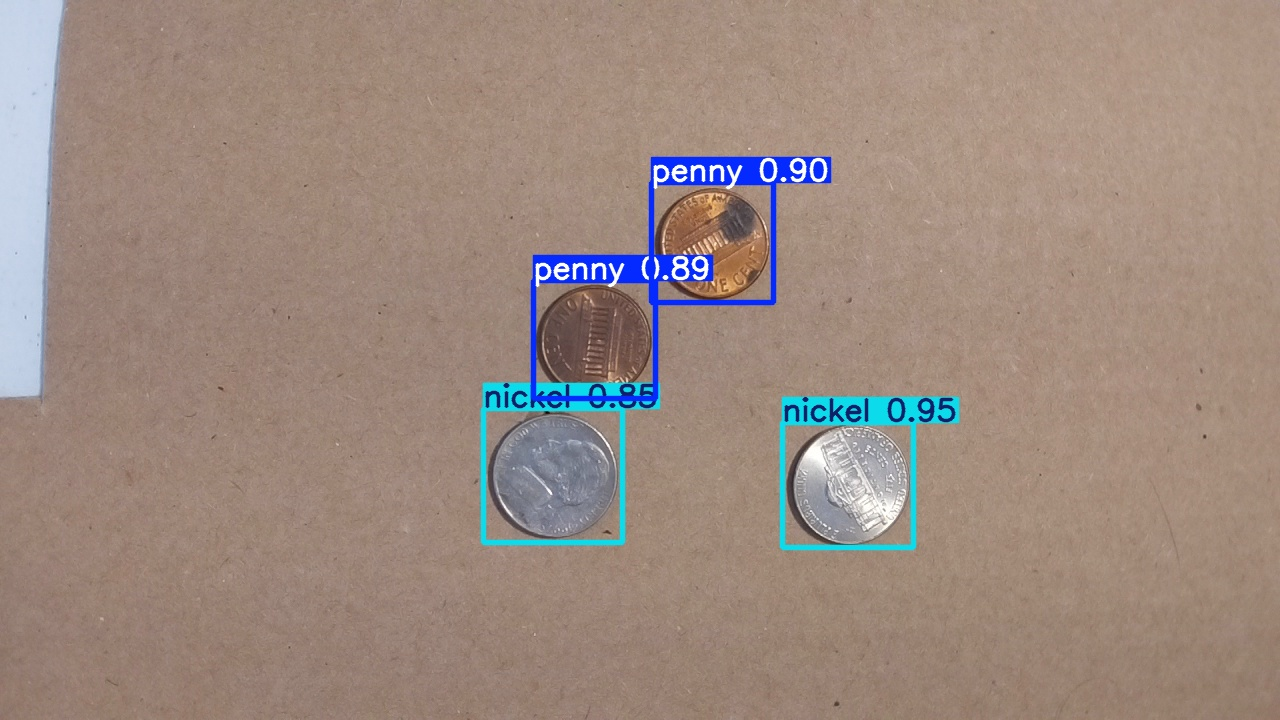

In [ ]:
import glob
from IPython.display import Image, display
for image_path in glob.glob(f'/content/runs/detect/predict/*.jpg')[:10]:
  display(Image(filename=image_path, height=400))
  print('\n')


We can also run the model on video files or other images images by uploading them to this notebook and using the above `!yolo detect predict` command, where `source` points to the location of the video file, image, or folder of images. The results will be saved in `runs/detect/predict`.

Drawing boxes on images is great, but it isn't very useful in itself. It's also not very helpful to just run this models inside a Colab notebook: it's easier if we can just run it on a local computer. Continue to the next section to see how to download your newly trained model and run it on a local device.

#7.&nbsp;Deploy Model

Now that the custom model has been trained, it's ready to be downloaded and deployed in an application! YOLO models can run on a wide variety of hardware, including PCs, embedded systems, and phones. Ultralytics makes it easy to convert the YOLO models to various formats (`tflite`, `onnx`, etc.) and deploy them in a variety of environments.

This section shows how to download the model and provides links to instructions for deploying it on your PC and edge devices like the Raspberry Pi.

## 7.1 Download YOLO Model

First, zip and download the trained model by running the code blocks below.

The code creates a folder named `my_model`, moves the model weights into it, and renames them from `best.pt` to `my_model.pt`. It also adds the training results in case you want to reference them later. It then zips the folder as `my_model.zip`.

In [ ]:
# Create "my_coin_model" folder to store model weights and train results
!mkdir /content/my_coin_model
!cp /content/runs/detect/train/weights/best.pt /content/my_coin_model/my_coin_model.pt
!cp -r /content/runs/detect/train /content/my_coin_model

# Zip into "my_coin_model.zip"
%cd my_coin_model
!zip /content/my_coin_model.zip my_coin_model.pt
!zip -r /content/my_coin_model.zip train
%cd /content

mkdir: cannot create directory ‘/content/my_coin_model’: File exists
/content/my_coin_model
  adding: my_coin_model.pt (deflated 8%)
updating: train/ (stored 0%)
updating: train/val_batch1_pred.jpg (deflated 10%)
updating: train/confusion_matrix_normalized.png (deflated 26%)
updating: train/val_batch2_labels.jpg (deflated 14%)
updating: train/val_batch0_pred.jpg (deflated 6%)
updating: train/train_batch2.jpg (deflated 4%)
updating: train/BoxP_curve.png (deflated 15%)
updating: train/train_batch1.jpg (deflated 6%)
updating: train/weights/ (stored 0%)
updating: train/weights/best.pt (deflated 8%)
updating: train/weights/last.pt (deflated 8%)
updating: train/val_batch2_pred.jpg (deflated 14%)
updating: train/train_batch0.jpg (deflated 4%)
updating: train/results.png (deflated 9%)
updating: train/BoxR_curve.png (deflated 13%)
updating: train/labels.jpg (deflated 34%)
updating: train/args.yaml (deflated 53%)
updating: train/confusion_matrix.png (deflated 29%)
updating: train/train_batch2152

In [ ]:
# This takes forever for some reason, you can also just download the model from the sidebar
from google.colab import files

files.download('/content/my_coin_model.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>